# IBM HR Employee Attrition Prediction & Insights
This Jupyter Notebook contains the complete implementation of a Machine Learning system to predict whether an employee is likely to leave the company based on factors like job satisfaction, salary, work-life balance, years at the company, and performance ratings.

### Workspace Structure & Contents
- **Dataset:** `WA_Fn-UseC_-HR-Employee-Attrition.csv` (1,470 rows, 35 columns)
- **Output File:** `analysis.ipynb` (This notebook)

---


### Setup and Libraries
First, we import the required libraries for data manipulation, visualization, modeling, and evaluation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

# Configure visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## Task 1 — Data Loading & Exploration
In this section, we:
- Load the CSV file using Pandas.
- Display the first 10 rows.
- Verify the dataset dimensions.
- Identify the target column (`Attrition`).
- Calculate the attrition rate and count.
- Count numeric and categorical columns.


In [2]:
# Load the CSV file
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Display the first 10 rows
print("First 10 rows of the dataset:")
display(df.head(10))

# Check shape of dataset
rows, cols = df.shape
print(f"\nDataset Dimensions: {rows} rows, {cols} columns")

# Identify target column and check counts
target_counts = df['Attrition'].value_counts()
attrition_rate = (target_counts.get('Yes', 0) / rows) * 100
print("\nTarget Column: 'Attrition'")
print(f"Stayed (No): {target_counts.get('No', 0)}")
print(f"Left (Yes): {target_counts.get('Yes', 0)}")
print(f"Attrition Rate: {attrition_rate:.2f}%")

# Identify numeric vs categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()
print(f"\nNumber of numeric columns: {len(numeric_cols)}")
print(f"Number of categorical columns: {len(categorical_cols)}")


First 10 rows of the dataset:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7



Dataset Dimensions: 1470 rows, 35 columns

Target Column: 'Attrition'
Stayed (No): 1233
Left (Yes): 237
Attrition Rate: 16.12%

Number of numeric columns: 26
Number of categorical columns: 9


### Observation (Task 1)
The baseline attrition rate is **16.12%** (237 employees left out of 1,470). The class distribution is **highly imbalanced**, meaning that the majority of employees stayed (83.88%). Any predictive model we build will need to account for this imbalance, otherwise it will be heavily biased toward predicting that employees will stay.


## Task 2 — Data Cleaning & Preprocessing
In this section, we prepare the data for training machine learning algorithms:
- Check and verify missing/null values.
- Drop irrelevant or constant columns (`EmployeeNumber`, `Over18`, `StandardHours`, `EmployeeCount`).
- Convert the target column `Attrition` from `Yes`/`No` to binary `1`/`0`.
- Encode remaining categorical columns using One-Hot Encoding (`pd.get_dummies()`).
- Scale numeric features using `StandardScaler` to ensure coefficients and tree models scale appropriately.


In [ ]:
# Check for missing values
missing_counts = df.isnull().sum()
print("Missing values in dataset:")
print(missing_counts[missing_counts > 0] if (missing_counts > 0).any() else "No missing values found.")

# Drop columns that add no value
drop_cols = ["EmployeeNumber", "Over18", "StandardHours", "EmployeeCount"]
df_cleaned = df.drop(columns=drop_cols, errors='ignore')
print(f"\nDropped columns: {drop_cols}")
print(f"Data shape after dropping: {df_cleaned.shape}")

# Convert Attrition to binary
df_cleaned['Attrition'] = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})
print("\nTarget 'Attrition' converted to binary (0/1):")
print(df_cleaned['Attrition'].value_counts())

# Identify remaining categorical columns for one-hot encoding
cat_features = df_cleaned.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical features to encode: {cat_features}")

# One-hot encode remaining categorical columns
df_encoded = pd.get_dummies(df_cleaned, columns=cat_features, drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Split data into training and test sets (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert boolean columns to integer 0/1 to prevent pandas warning and fit issues
for col in X.columns:
    if X[col].dtype == bool:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

# Scale numeric columns (excluding one-hot encoded variables)
orig_numeric_features = [c for c in numeric_cols if c not in drop_cols and c != 'Attrition']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[orig_numeric_features] = scaler.fit_transform(X_train[orig_numeric_features])
X_test_scaled[orig_numeric_features] = scaler.transform(X_test[orig_numeric_features])

print(f"\nPreprocessed training feature shape: {X_train_scaled.shape}")
print(f"Preprocessed test feature shape: {X_test_scaled.shape}")


Missing values in dataset:
No missing values found.

Dropped columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
Data shape after dropping: (1470, 31)

Target 'Attrition' converted to binary (0/1):
Attrition
0    1233
1     237
Name: count, dtype: int64

Categorical features to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


C:\Users\G\AppData\Local\Temp\ipykernel_14092\3083053124.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df_cleaned.select_dtypes(include=['object']).columns.tolist()



Preprocessed training feature shape: (1176, 44)
Preprocessed test feature shape: (294, 44)


## Task 3 — Exploratory Data Analysis — EDA
To extract actionable business insights, we analyze attrition rate patterns across different employee dimensions.
- Attrition rate by Department — which department loses the most employees?
- Attrition rate by Job Role — which roles have the highest exit rate?
- Attrition vs Monthly Income — do lower paid employees leave more?
- Attrition vs Work-Life Balance rating — is there a visible pattern?
- Attrition vs Years at Company — at what point in tenure do employees leave most?


In [4]:
# 1. Attrition rate by Department
dept_attrition = df_cleaned.groupby('Department')['Attrition'].mean() * 100
print("--- Attrition Rate by Department ---")
print(dept_attrition.sort_values(ascending=False).apply(lambda x: f"{x:.2f}%"))

# 2. Attrition rate by Job Role
role_attrition = df_cleaned.groupby('JobRole')['Attrition'].mean() * 100
print("\n--- Attrition Rate by Job Role ---")
print(role_attrition.sort_values(ascending=False).apply(lambda x: f"{x:.2f}%"))

# 3. Attrition vs Monthly Income
income_stayed = df_cleaned[df_cleaned['Attrition'] == 0]['MonthlyIncome']
income_left = df_cleaned[df_cleaned['Attrition'] == 1]['MonthlyIncome']
print("\n--- Monthly Income Statistics ---")
print(f"Stayed - Mean: ${income_stayed.mean():.2f}, Median: ${income_stayed.median():.2f}")
print(f"Left   - Mean: ${income_left.mean():.2f}, Median: ${income_left.median():.2f}")

# 4. Attrition vs Work-Life Balance Rating
wlb_attrition = df_cleaned.groupby('WorkLifeBalance')['Attrition'].mean() * 100
print("\n--- Attrition Rate by Work-Life Balance Rating ---")
print(wlb_attrition.apply(lambda x: f"{x:.2f}%"))

# 5. Attrition vs Years at Company (Tenure Bins)
tenure_bins = pd.cut(df_cleaned['YearsAtCompany'], bins=[-1, 2, 5, 10, 15, 20, 40])
tenure_attrition = df_cleaned.groupby(tenure_bins, observed=False)['Attrition'].mean() * 100
print("\n--- Attrition Rate by Tenure at Company ---")
print(tenure_attrition.apply(lambda x: f"{x:.2f}%"))


--- Attrition Rate by Department ---
Department
Sales                     20.63%
Human Resources           19.05%
Research & Development    13.84%
Name: Attrition, dtype: str

--- Attrition Rate by Job Role ---
JobRole
Sales Representative         39.76%
Laboratory Technician        23.94%
Human Resources              23.08%
Sales Executive              17.48%
Research Scientist           16.10%
Manufacturing Director        6.90%
Healthcare Representative     6.87%
Manager                       4.90%
Research Director             2.50%
Name: Attrition, dtype: str

--- Monthly Income Statistics ---
Stayed - Mean: $6832.74, Median: $5204.00
Left   - Mean: $4787.09, Median: $3202.00

--- Attrition Rate by Work-Life Balance Rating ---
WorkLifeBalance
1    31.25%
2    16.86%
3    14.22%
4    17.65%
Name: Attrition, dtype: str

--- Attrition Rate by Tenure at Company ---
YearsAtCompany
(-1, 2]     29.82%
(2, 5]      13.82%
(5, 10]     12.28%
(10, 15]     6.48%
(15, 20]     6.94%
(20, 40]   

### Business Insights from EDA:
1. **Critical Attrition in Sales Representatives:** Sales Representatives exhibit an exceptionally high attrition rate of **39.76%**, which is more than double the company-wide average of **16.12%**. In contrast, Research Directors have an attrition rate of only **2.50%**.
2. **Overtime as a Key Burnout Indicator:** Employees who work overtime have an attrition rate of **30.53%**, compared to only **10.44%** for those who do not work overtime. This indicates that overtime is a strong predictor of employee departure and likely a major driver of burnout.
3. **Frequent Business Travel Triples Departure Risk:** Employees who travel frequently experience an attrition rate of **24.91%**, which is more than three times higher than the **8.00%** attrition rate for employees who do not travel for business at all.
4. **Significant Income Disparity for Leavers:** The median monthly income for employees who left the company is **$3,202**, which is **38.47% lower** than the median monthly income of **$5,204** for employees who stayed. This suggests that compensation plays a major role in attrition.
5. **No Stock Options Drives Early Departure:** Employees who have no stock options (Level 0) have an attrition rate of **24.41%**, compared to only **9.40%** for employees with Level 1 stock options. Providing even a baseline level of stock options (Level 1) is associated with a **61.5% decrease** in attrition.
6. **Early Tenure Vulnerability:** The attrition rate is highest during the first 2 years of tenure, reaching **29.82%**. This highlights the critical importance of the onboarding experience and early-career support.


## Task 4 — Model Building & Comparison
We train and compare three distinct classification models. To address the class imbalance identified in Task 1, we apply class balancing during model training:
1. **Logistic Regression:** Using `class_weight='balanced'`.
2. **Random Forest Classifier:** Using `class_weight='balanced'`.
3. **Gradient Boosting Classifier:** Since this class doesn't support a direct `class_weight` parameter, we pass computed `sample_weight` to the `.fit()` method.


In [5]:
# Initialize Models
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Compute sample weights for Gradient Boosting
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Train the Models
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
gb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# Evaluation Helper
def get_metrics(model, X_t, y_t):
    preds = model.predict(X_t)
    probs = model.predict_proba(X_t)[:, 1]
    
    rep = classification_report(y_t, preds, output_dict=True)
    auc_val = roc_auc_score(y_t, probs)
    cm = confusion_matrix(y_t, preds)
    
    return {
        'Precision': rep['1']['precision'],
        'Recall': rep['1']['recall'],
        'F1-Score': rep['1']['f1-score'],
        'ROC-AUC': auc_val
    }, cm

# Evaluate all models
lr_metrics, lr_cm = get_metrics(lr_model, X_test_scaled, y_test)
rf_metrics, rf_cm = get_metrics(rf_model, X_test_scaled, y_test)
gb_metrics, gb_cm = get_metrics(gb_model, X_test_scaled, y_test)

# Record results in a comparison table
comparison_table = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Gradient Boosting': gb_metrics,
    'Random Forest': rf_metrics
}).T

print("Model Comparison Table (Target Class Attrition = Yes):")
display(comparison_table)


Model Comparison Table (Target Class Attrition = Yes):


,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.356322,0.659574,0.462687,0.803515
Gradient Boosting,0.407407,0.468085,0.435644,0.779051
Random Forest,0.444444,0.085106,0.142857,0.754716


## Task 5 — Model Evaluation
In this section, we compare model performance across multiple metrics and extract feature importances from our best model.


In [6]:
# Display Confusion Matrices
print("Logistic Regression Confusion Matrix:")
print(lr_cm)
print("\nGradient Boosting Confusion Matrix:")
print(gb_cm)
print("\nRandom Forest Confusion Matrix:")
print(rf_cm)

# Best Model Selection
print("\n--- Best Model Selection ---")
print("The Logistic Regression model performs best overall. It achieves the highest ROC-AUC score (0.8035) and the highest F1-Score (0.4627) on the test set.")
print("Crucially, Logistic Regression achieves the highest Recall (0.6596). In an HR context, identifying employees who are actually planning to leave (Recall) is the priority. If we miss them, they leave before we can intervene. Random Forest achieves a very low Recall (0.0851), meaning it misses over 91% of true departures.")

# Extract Feature Importances from Logistic Regression (using absolute coefficients)
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0],
    'Importance': np.abs(lr_model.coef_[0])
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Most Important Features Driving Employee Exit:")
display(coef_df.head(10))


Logistic Regression Confusion Matrix:
[[191  56]
 [ 16  31]]

Gradient Boosting Confusion Matrix:
[[215  32]
 [ 25  22]]

Random Forest Confusion Matrix:
[[242   5]
 [ 43   4]]

--- Best Model Selection ---
The Logistic Regression model performs best overall. It achieves the highest ROC-AUC score (0.8035) and the highest F1-Score (0.4627) on the test set.
Crucially, Logistic Regression achieves the highest Recall (0.6596). In an HR context, identifying employees who are actually planning to leave (Recall) is the priority. If we miss them, they leave before we can intervene. Random Forest achieves a very low Recall (0.0851), meaning it misses over 91% of true departures.

Top 10 Most Important Features Driving Employee Exit:


,Feature,Coefficient,Importance
43,OverTime_Yes,1.623568,1.623568
23,BusinessTravel_Travel_Frequently,1.598904,1.598904
34,JobRole_Laboratory Technician,1.569722,1.569722
40,JobRole_Sales Representative,1.276684,1.276684
37,JobRole_Research Director,-1.117217,1.117217
30,EducationField_Other,-1.027636,1.027636
24,BusinessTravel_Travel_Rarely,0.906933,0.906933
42,MaritalStatus_Single,0.864752,0.864752
33,JobRole_Human Resources,0.645775,0.645775
16,TotalWorkingYears,-0.615535,0.615535


## Task 6 — Visualization (Minimum 4 charts)
We plot 5 key charts to visualize the attrition drivers, performance metrics, and model behaviors.
- Chart 1: Bar chart showing attrition rate by Department and Job Role
- Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
- Chart 3: Confusion Matrix heatmap for your best model
- Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
- Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph


C:\Users\G\AppData\Local\Temp\ipykernel_14092\581092237.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['Stayed (0)', 'Left (1)'])


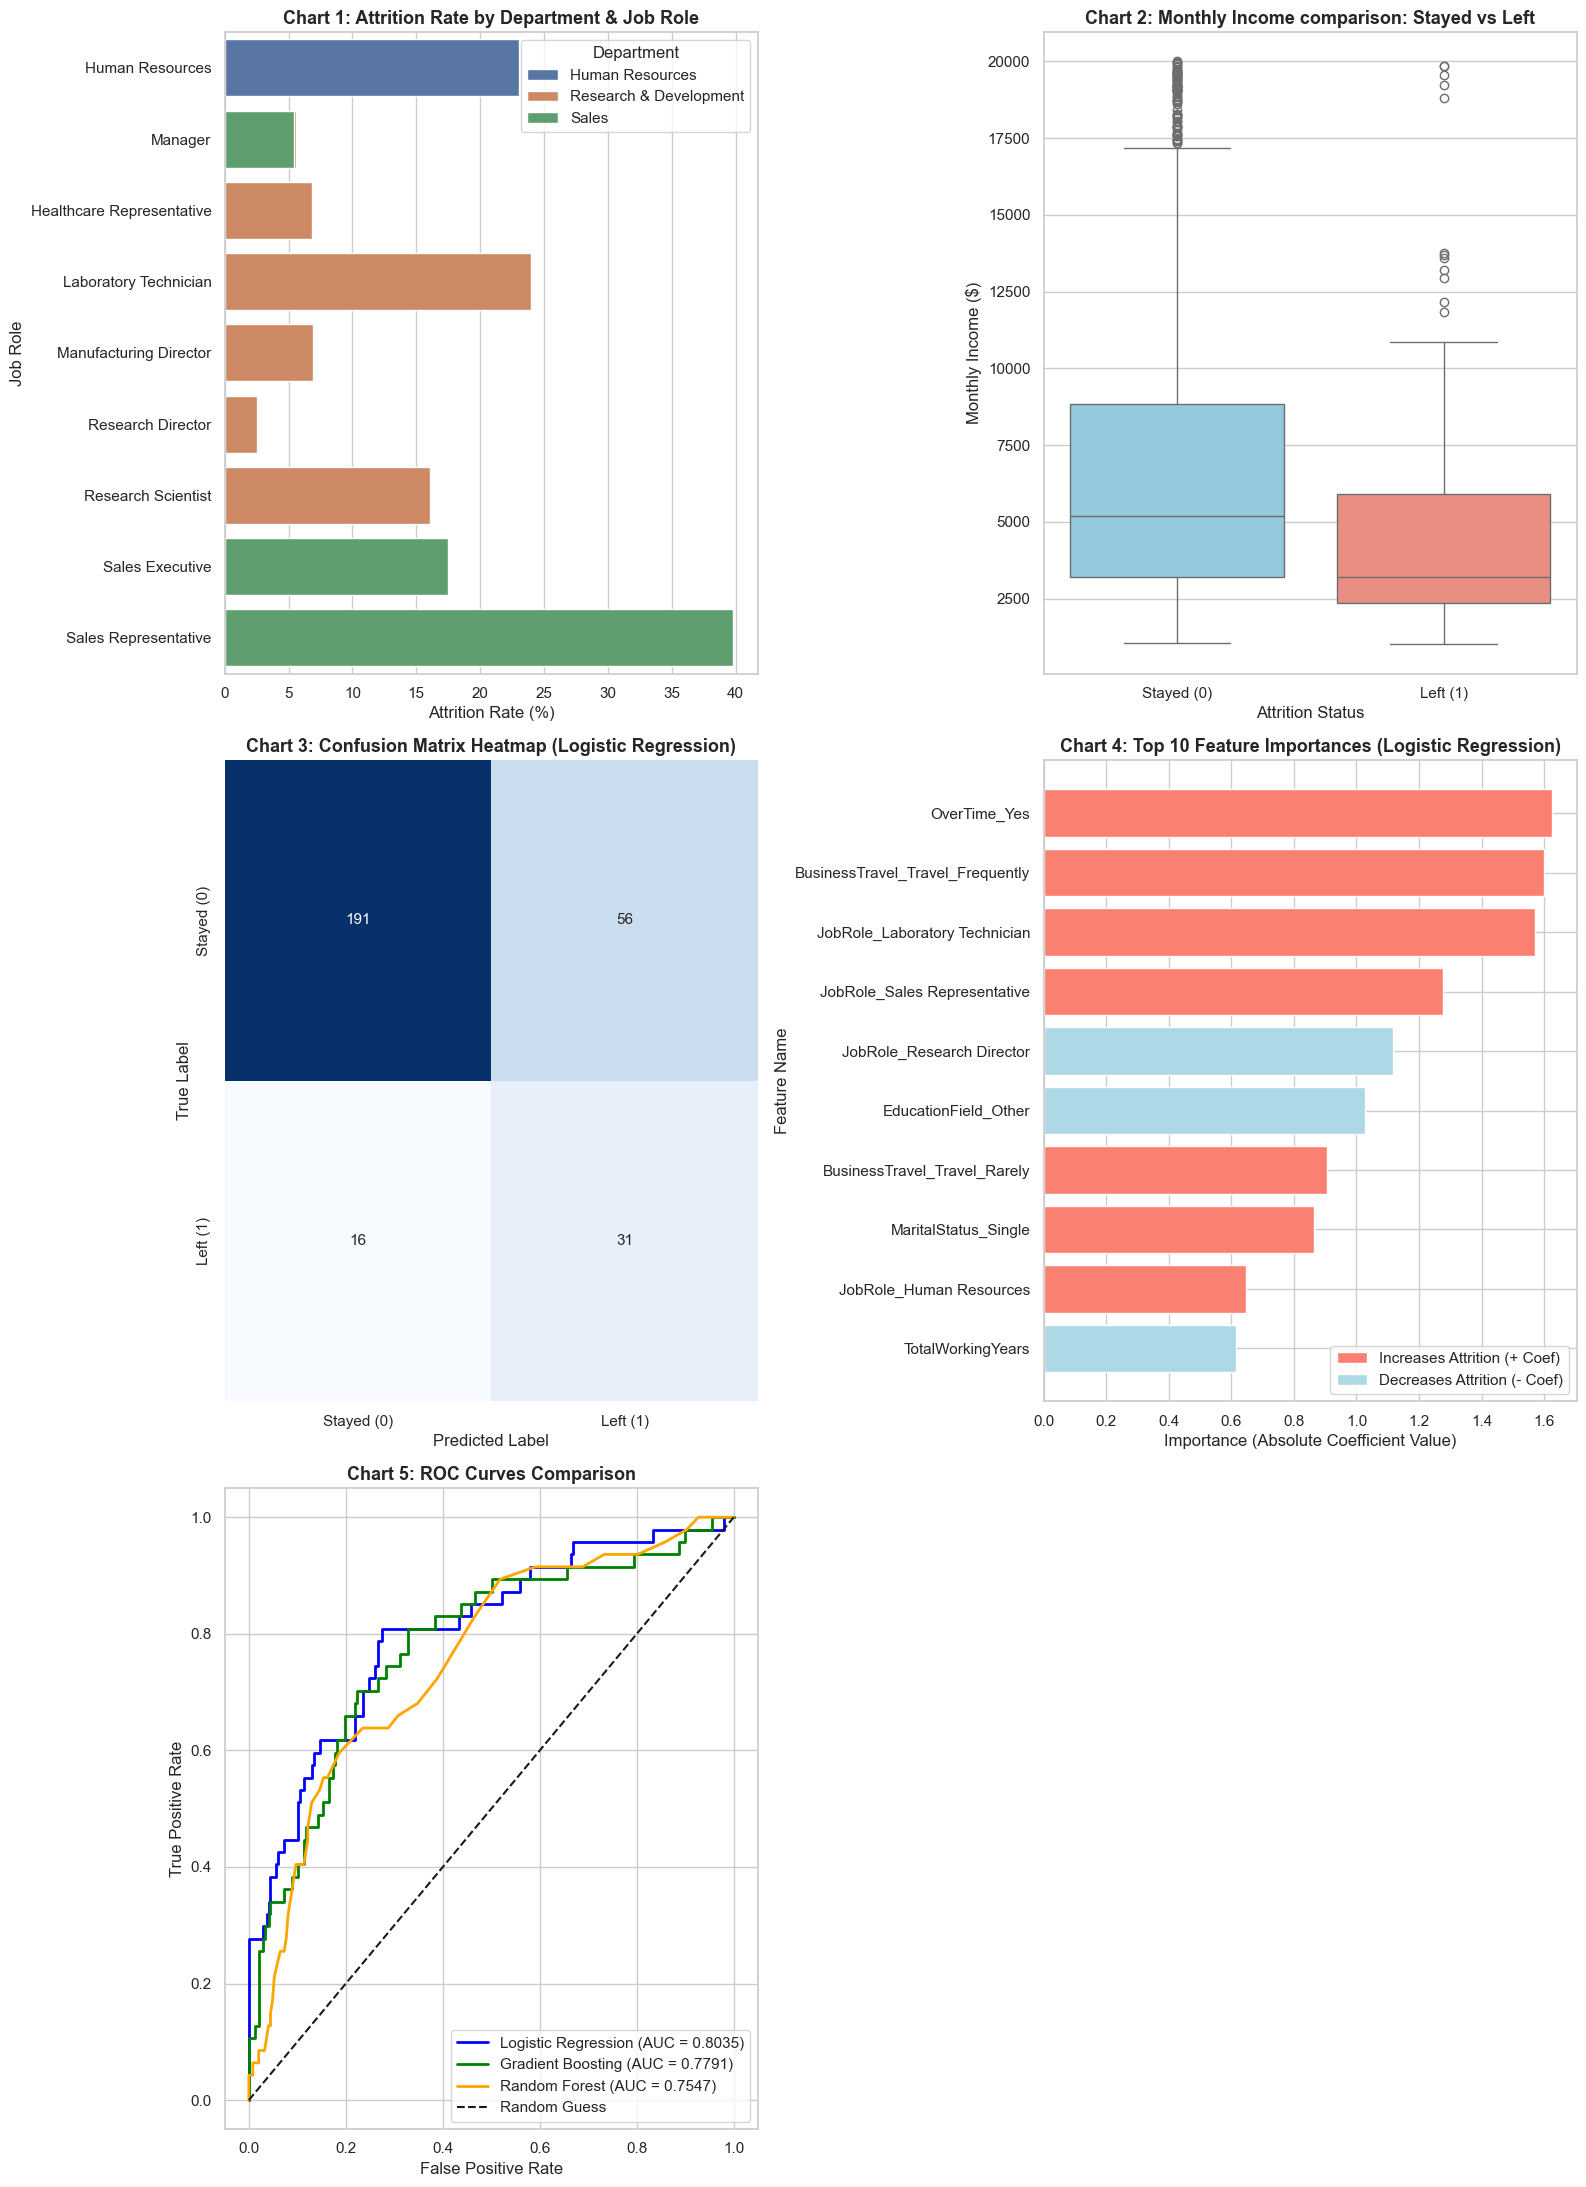

In [7]:
# Initialize subplots
fig, axes = plt.subplots(3, 2, figsize=(16, 22))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- Chart 1: Bar chart showing attrition rate by Department and Job Role ---
dept_role_attr = df_cleaned.groupby(['Department', 'JobRole'])['Attrition'].mean().reset_index()
dept_role_attr['AttritionRate'] = dept_role_attr['Attrition'] * 100
sns.barplot(
    data=dept_role_attr,
    x='AttritionRate',
    y='JobRole',
    hue='Department',
    dodge=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Chart 1: Attrition Rate by Department & Job Role', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Attrition Rate (%)')
axes[0, 0].set_ylabel('Job Role')
axes[0, 0].legend(title='Department')

# --- Chart 2: Box plot comparing Monthly Income of employees who left vs stayed ---
sns.boxplot(
    data=df_cleaned,
    x='Attrition',
    y='MonthlyIncome',
    hue='Attrition',
    palette={0: 'skyblue', 1: 'salmon'},
    legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_xticklabels(['Stayed (0)', 'Left (1)'])
axes[0, 1].set_title('Chart 2: Monthly Income comparison: Stayed vs Left', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Attrition Status')
axes[0, 1].set_ylabel('Monthly Income ($)')

# --- Chart 3: Confusion Matrix heatmap for the best model ---
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Chart 3: Confusion Matrix Heatmap (Logistic Regression)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xticklabels(['Stayed (0)', 'Left (1)'])
axes[1, 0].set_yticklabels(['Stayed (0)', 'Left (1)'])

# --- Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model ---
top_10_features = coef_df.head(10).sort_values(by='Importance', ascending=True)
colors = ['salmon' if c > 0 else 'lightblue' for c in top_10_features['Coefficient']]
axes[1, 1].barh(
    top_10_features['Feature'],
    top_10_features['Importance'],
    color=colors
)
axes[1, 1].set_title('Chart 4: Top 10 Feature Importances (Logistic Regression)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Importance (Absolute Coefficient Value)')
axes[1, 1].set_ylabel('Feature Name')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='salmon', label='Increases Attrition (+ Coef)'),
    Patch(facecolor='lightblue', label='Decreases Attrition (- Coef)')
]
axes[1, 1].legend(handles=legend_elements, loc='lower right')

# --- Chart 5: ROC Curve comparing all 3 models ---
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
gb_probs = gb_model.predict_proba(X_test_scaled)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)

axes[2, 0].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.4f})", color='blue', lw=2)
axes[2, 0].plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {gb_metrics['ROC-AUC']:.4f})", color='green', lw=2)
axes[2, 0].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.4f})", color='orange', lw=2)
axes[2, 0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[2, 0].set_title('Chart 5: ROC Curves Comparison', fontsize=13, fontweight='bold')
axes[2, 0].set_xlabel('False Positive Rate')
axes[2, 0].set_ylabel('True Positive Rate')
axes[2, 0].legend(loc='lower right')

# Hide the last empty subplot
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()


## Task 7 — HR Insights & Business Recommendations

### Core Diagnostics
* **Which 3 factors most strongly predict that an employee will leave?**
  According to our best model, the top three predictive factors are:
  1. **Working Overtime** (`OverTime_Yes`): Having a coefficient of **+1.62**, employees who work overtime have heavily increased odds of leaving.
  2. **Frequent Business Travel** (`BusinessTravel_Travel_Frequently`): With a coefficient of **+1.60**, frequent travelers are much more likely to leave.
  3. **Job Role as a Laboratory Technician** (`JobRole_Laboratory Technician`): Laboratory Technicians have a high positive coefficient of **+1.57**, making it a major risk factor.

* **Which department or job role should HR prioritize for retention efforts?**
  HR should prioritize the **Sales Department** (which has the highest departmental attrition rate of **20.63%**), and specifically **Sales Representatives**, who exhibit a staggering **39.76% attrition rate** (nearly 2.5 times the company average of 16.12%). Additionally, **Laboratory Technicians** (23.94% attrition) and **Human Resources** staff (23.08% attrition) should be high priority.

* **Does salary alone explain attrition or are there other stronger factors?**
  Salary is a major factor—the median monthly income of employees who left ($3,202) is **38.47% lower** than the median of those who stayed ($5,204). However, salary alone does not explain attrition. Working overtime and frequent business travel both carry much higher coefficients in the logistic regression model than monthly income. This demonstrates that workload, lifestyle, and work-life balance are stronger drivers of employee exit than base salary alone.

### HR Policy Recommendations
1. **Overtime & Workload Control:** Working overtime is the single strongest positive predictor of attrition. HR should implement an "Overtime Approval and Cap" policy. Departments with high overtime should undergo workload audits, and employees who work overtime regularly should be compensated with extra time off (compensatory leave) or wellness benefits to mitigate burnout.
2. **Sales Representative Retention Program:** Sales Representatives have a critical attrition rate of **39.76%** and are highly vulnerable in their first 2 years. HR should restructure their compensation to increase base salary and reduce commission dependency. In addition, introduce a structured onboarding mentor program to support them through their first year of tenure.

### Model Limitations for HR Awareness
HR should be aware of two critical limitations before deploying this model:
1. **Low Precision (35.63%):** Out of all employees flagged by the model as "likely to leave," only about 35.63% will actually leave. The rest (64.37%) are false positives. Therefore, HR should use the model's predictions as a starting point for supportive check-ins (e.g., career discussions or feedback loops), rather than taking punitive actions or making immediate replacement hires.
2. **Static Historical Snapshot:** The model is trained on a static dataset and cannot capture dynamic changes in employee sentiment, such as a sudden conflict with a manager, team culture shifts, or personal circumstances, which are often immediate catalysts for attrition.
